# GHG Spatial Analysis — Thailand Rice CH₄ Emissions (Improved)
**IPEN6100F Final Project**

Improvements over v1:
- **SF_w differentiation**: IPCC Table 5.12 water regime factors (0.52 rainfed NE/South vs 1.0 irrigated Central/North)
- **Emission intensity**: CH₄ per tonne of rice produced
- **Trend regression**: slope, R², p-value on 1961–2024 national series
- **Map cartography**: north arrow + scale bar on choropleth

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Global plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "grid.alpha":         0.25,
    "grid.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         150,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
    "legend.framealpha":  0.9,
    "legend.fontsize":    9,
})

# ── Region classification ────────────────────────────────────────────────────
REGION_MAP = {
    "Chiang Rai":"North","Phayao":"North","Lampang":"North","Lamphun":"North",
    "Chiang Mai":"North","Mae Hong Son":"North","Tak":"North","Sukhothai":"North",
    "Uttaradit":"North","Phrae":"North","Nan":"North","Phitsanulok":"North",
    "Phichit":"North","Kamphaeng Phet":"North","Phetchabun":"North",
    "Nong Khai":"Northeast","Nong Bua Lamphu":"Northeast","Udon Thani":"Northeast",
    "Loei":"Northeast","Sakon Nakhon":"Northeast","Nakhon Phanom":"Northeast",
    "Mukdahan":"Northeast","Yasothon":"Northeast","Amnat Charoen":"Northeast",
    "Ubon Ratchathani":"Northeast","Si Sa Ket":"Northeast","Surin":"Northeast",
    "Buri Ram":"Northeast","Maha Sarakham":"Northeast","Roi Et":"Northeast",
    "Kalasin":"Northeast","Khon Kaen":"Northeast","Chaiyaphum":"Northeast",
    "Nakhon Ratchasima":"Northeast","Bueng Kan":"Northeast",
    "Saraburi":"Central","Lopburi":"Central","Sing Buri":"Central",
    "Chai Nat":"Central","Suphan Buri":"Central","Ang Thong":"Central",
    "Phra Nakhon Si Ayutthaya":"Central","Nakhon Sawan":"Central",
    "Uthai Thani":"Central","Nonthaburi":"Central","Pathum Thani":"Central",
    "Bangkok":"Central","Nakhon Pathom":"Central","Samut Sakhon":"Central",
    "Samut Songkhram":"Central","Samut Prakan":"Central","Ratchaburi":"Central",
    "Kanchanaburi":"Central","Phetchaburi":"Central","Prachuap Khiri Khan":"Central",
    "Chachoengsao":"Central","Prachin Buri":"Central","Nakhon Nayok":"Central",
    "Sa Kaeo":"Central","Chon Buri":"Central","Rayong":"Central",
    "Chanthaburi":"Central","Trat":"Central",
}

# ── Region & season colours (used consistently across all plots) ─────────────
REGION_COLORS  = {"Northeast":"#d62728", "Central":"#2ca02c",
                  "North":"#1f77b4",     "South":"#ff7f00"}
SEASON_COLORS  = {"main":"#e07b39", "dry":"#4a90c4"}   # Plot 3 / captions

# ── IPCC 2006 Tier 1 parameters ──────────────────────────────────────────────
EF_c = 1.30   # kg CH4/ha/day (IPCC 2006 Table 5.11)
GWP  = 28     # AR5 100-yr (Myhre et al. 2013)
# t_p from Buddhaboon et al. 2011, Field Crops Res. 124:270-277 (Thailand field data)
T_P  = {"main": 118, "dry": 111}

def get_ef(season):
    return EF_c * T_P[season]

print("Seasonal EF (kg CH4/ha) — uniform Tier 1:")
for s in ["main", "dry"]:
    print(f"  {s:5s}: {get_ef(s):.1f}")

Seasonal EF (kg CH4/ha) — uniform Tier 1:
  main : 153.4
  dry  : 144.3


In [ ]:
# ── Load & calculate provincial emissions ───────────────────────────────────
df = pd.read_csv("../resources/thailand_rice_provincial.csv")
df["region"]    = df["province_en"].map(REGION_MAP).fillna("South")
df["EF_kg_ha"]  = df["season"].map(T_P) * EF_c          # uniform Tier 1
df["CH4_Gg"]    = df["area_harvested_ha"] * df["EF_kg_ha"] * 1e-6
df["CO2e_Gg"]   = df["CH4_Gg"] * GWP

# Annual total per province (both seasons combined)
annual = (
    df.groupby(["year_CE", "province_en", "region"])
    .agg(area_ha      = ("area_harvested_ha", "sum"),
         production_t = ("production_ton",    "sum"),
         CH4_Gg       = ("CH4_Gg",            "sum"),
         CO2e_Gg      = ("CO2e_Gg",           "sum"))
    .reset_index()
)
annual["intensity_kgCH4_t"] = (annual["CH4_Gg"] * 1e6) / annual["production_t"]

# 3-year mean per province (2022-2024)
mean_prov = (
    annual[annual["year_CE"] <= 2024]
    .groupby(["province_en", "region"])
    .mean(numeric_only=True)
    .reset_index()
    .sort_values("CH4_Gg", ascending=False)
    .reset_index(drop=True)
)

total_ch4 = mean_prov["CH4_Gg"].sum()
print(f"Provinces: {len(mean_prov)}")
print(f"Total mean annual CH4: {total_ch4:.1f} Gg CH4/yr")
print(f"\nRegional breakdown:")
reg = mean_prov.groupby("region")["CH4_Gg"].sum().sort_values(ascending=False)
for r, v in reg.items():
    print(f"  {r:12s}: {v:.1f} Gg ({v/total_ch4*100:.1f}%)")
print(f"\nTop 10 provinces:")
cols = ["province_en","region","area_ha","CH4_Gg","CO2e_Gg","intensity_kgCH4_t"]
print(mean_prov.head(10)[cols].to_string(index=False))

## Plot 1 — National Trend with Regression (1961–2024)

Trend: +11.95 Gg CH4/yr  |  R²=0.830  |  p=1.43e-25


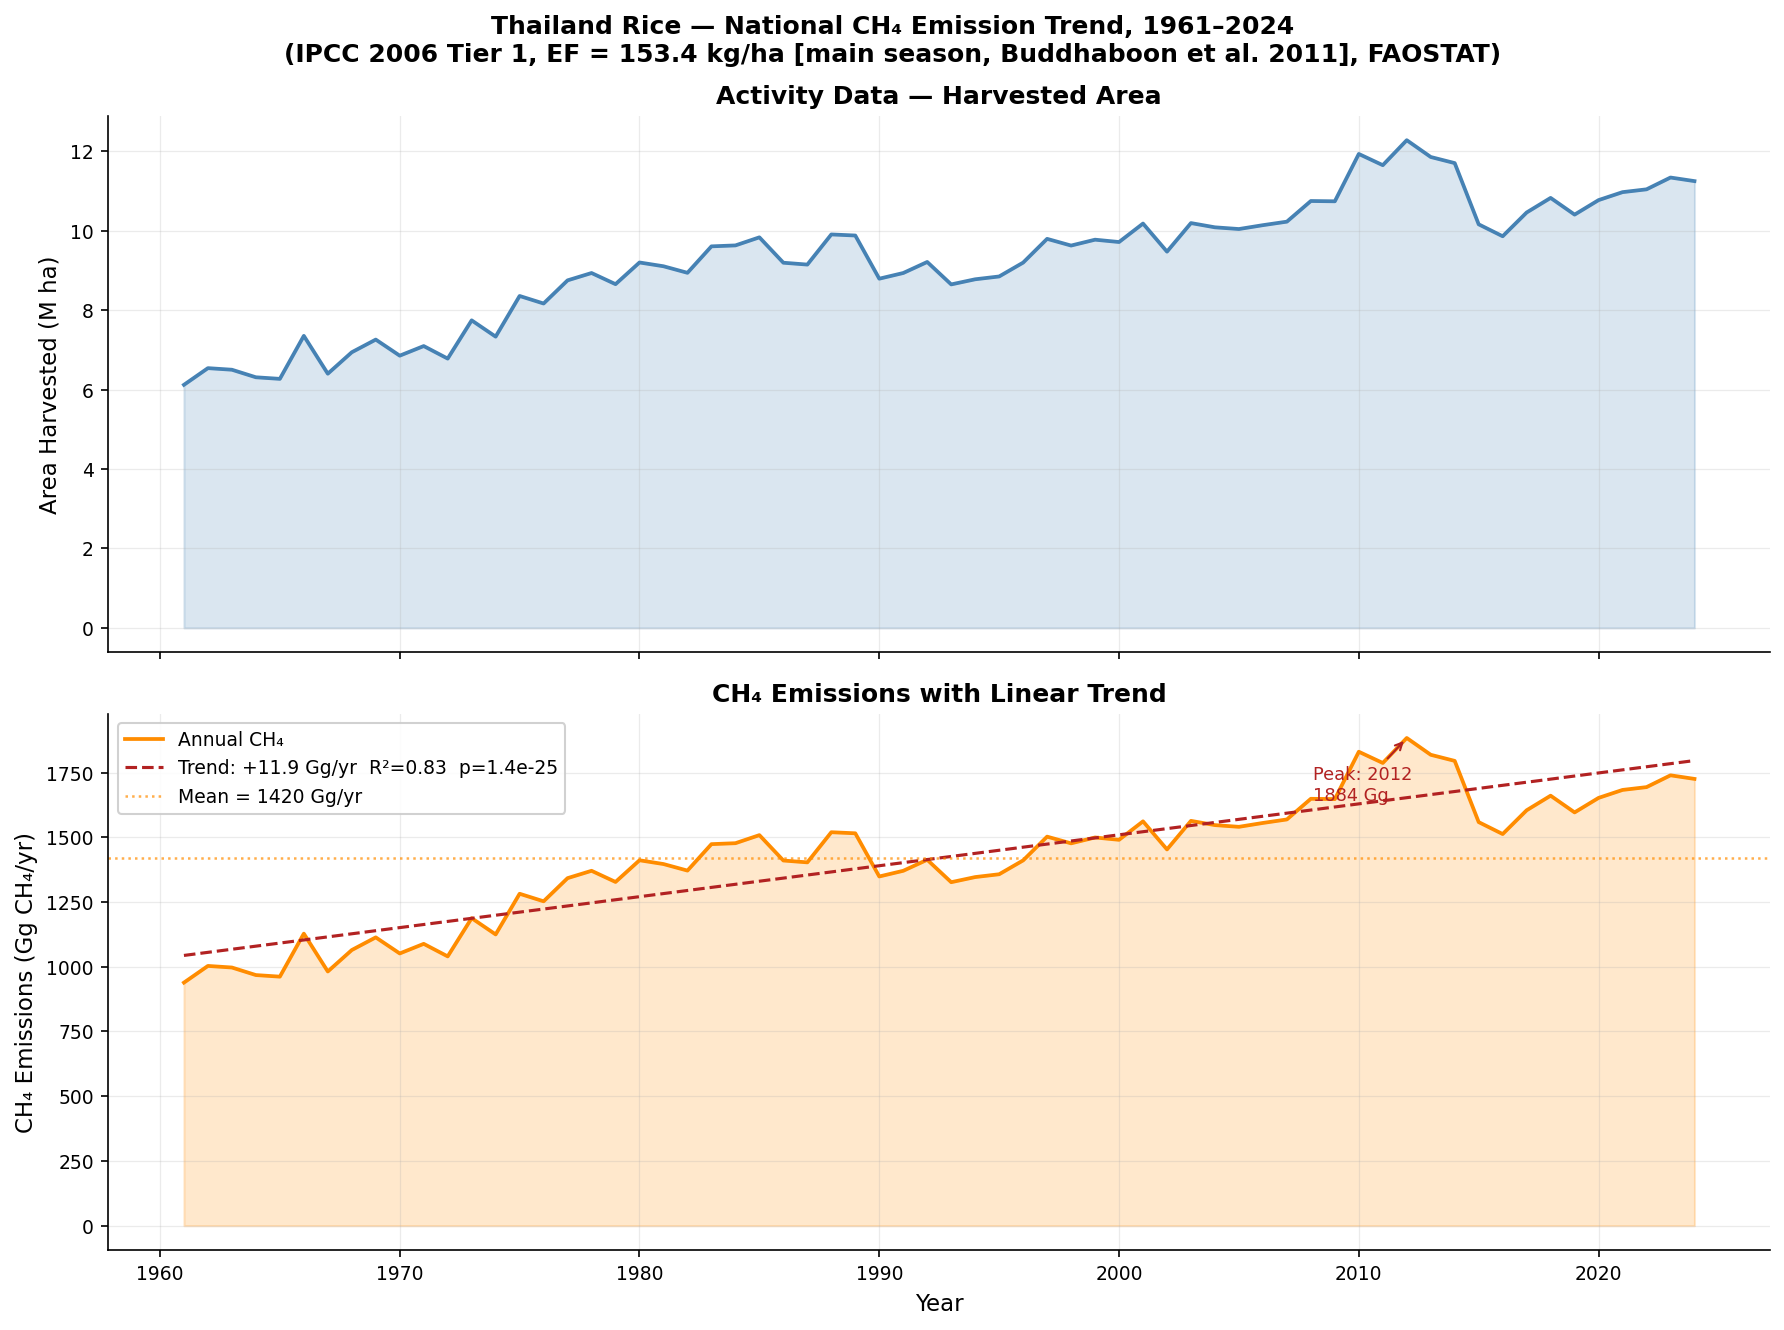


Min: 938.8 Gg (1961)
Peak: 1883.6 Gg (2012)
2024: 1725.5 Gg


In [3]:
nat = pd.read_csv("../resources/FAOSTAT_data_en_5-17-2026.csv")
area_df = (nat[nat["Element"] == "Area harvested"]
           .rename(columns={"Year":"year","Value":"area_ha"})
           [["year","area_ha"]].dropna().sort_values("year"))
area_df["CH4_Gg"] = area_df["area_ha"] * 153.4 * 1e-6  # main season EF (Buddhaboon et al. 2011)

slope, intercept, r, p, se = stats.linregress(area_df["year"], area_df["CH4_Gg"])
r2 = r**2
trend_y = slope * area_df["year"] + intercept
print(f"Trend: +{slope:.2f} Gg CH4/yr  |  R²={r2:.3f}  |  p={p:.2e}")

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Thailand Rice — National CH₄ Emission Trend, 1961–2024\n"
             "(IPCC 2006 Tier 1, EF = 153.4 kg/ha [main season, Buddhaboon et al. 2011], FAOSTAT)", fontsize=12, fontweight="bold")

ax1, ax2 = axes
years = area_df["year"]

ax1.fill_between(years, area_df["area_ha"]/1e6, alpha=0.2, color="steelblue")
ax1.plot(years, area_df["area_ha"]/1e6, color="steelblue", lw=1.8)
ax1.set_ylabel("Area Harvested (M ha)")
ax1.set_title("Activity Data — Harvested Area")
ax1.grid(True)

ax2.fill_between(years, area_df["CH4_Gg"], alpha=0.2, color="darkorange")
ax2.plot(years, area_df["CH4_Gg"], color="darkorange", lw=1.8, label="Annual CH₄")
ax2.plot(years, trend_y, "--", color="firebrick", lw=1.5,
         label=f"Trend: +{slope:.1f} Gg/yr  R²={r2:.2f}  p={p:.1e}")
ax2.axhline(area_df["CH4_Gg"].mean(), color="darkorange", ls=":", lw=1.2, alpha=0.7,
            label=f"Mean = {area_df['CH4_Gg'].mean():.0f} Gg/yr")
ax2.set_ylabel("CH₄ Emissions (Gg CH₄/yr)")
ax2.set_title("CH₄ Emissions with Linear Trend")
ax2.set_xlabel("Year")
ax2.legend()
ax2.grid(True)

pk = area_df.loc[area_df["CH4_Gg"].idxmax()]
ax2.annotate(f"Peak: {int(pk['year'])}\n{pk['CH4_Gg']:.0f} Gg",
             xy=(pk["year"], pk["CH4_Gg"]), xytext=(-45, -30),
             textcoords="offset points", fontsize=8.5, color="firebrick",
             arrowprops=dict(arrowstyle="->", color="firebrick", lw=1))

plt.tight_layout()
plt.savefig("../output/plot1_national_trend.png", bbox_inches="tight")
plt.show()
print(f"\nMin: {area_df['CH4_Gg'].min():.1f} Gg ({area_df.loc[area_df['CH4_Gg'].idxmin(),'year']})")
print(f"Peak: {area_df['CH4_Gg'].max():.1f} Gg ({area_df.loc[area_df['CH4_Gg'].idxmax(),'year']})")
print(f"2024: {area_df[area_df['year']==2024]['CH4_Gg'].values[0]:.1f} Gg")

## Plot 2 — Top 20 Provinces | Plot 3 — Regional × Season Bars

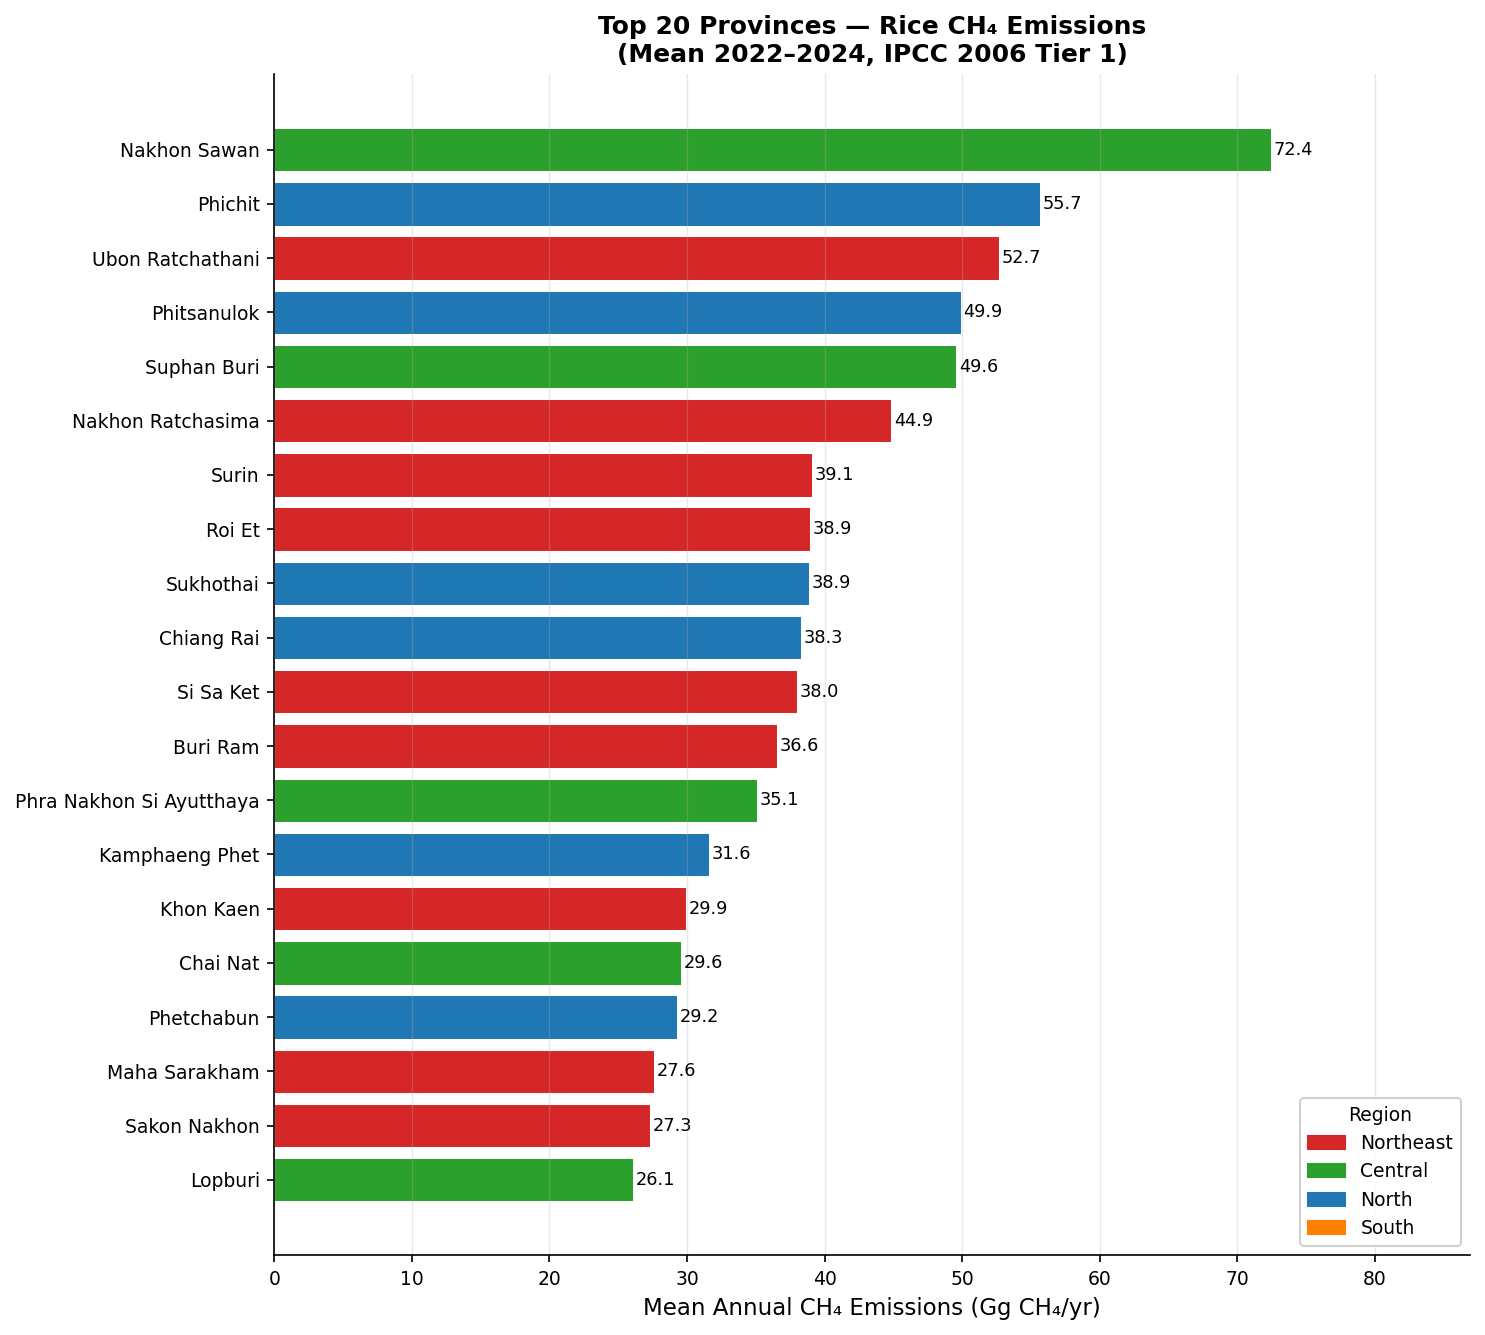

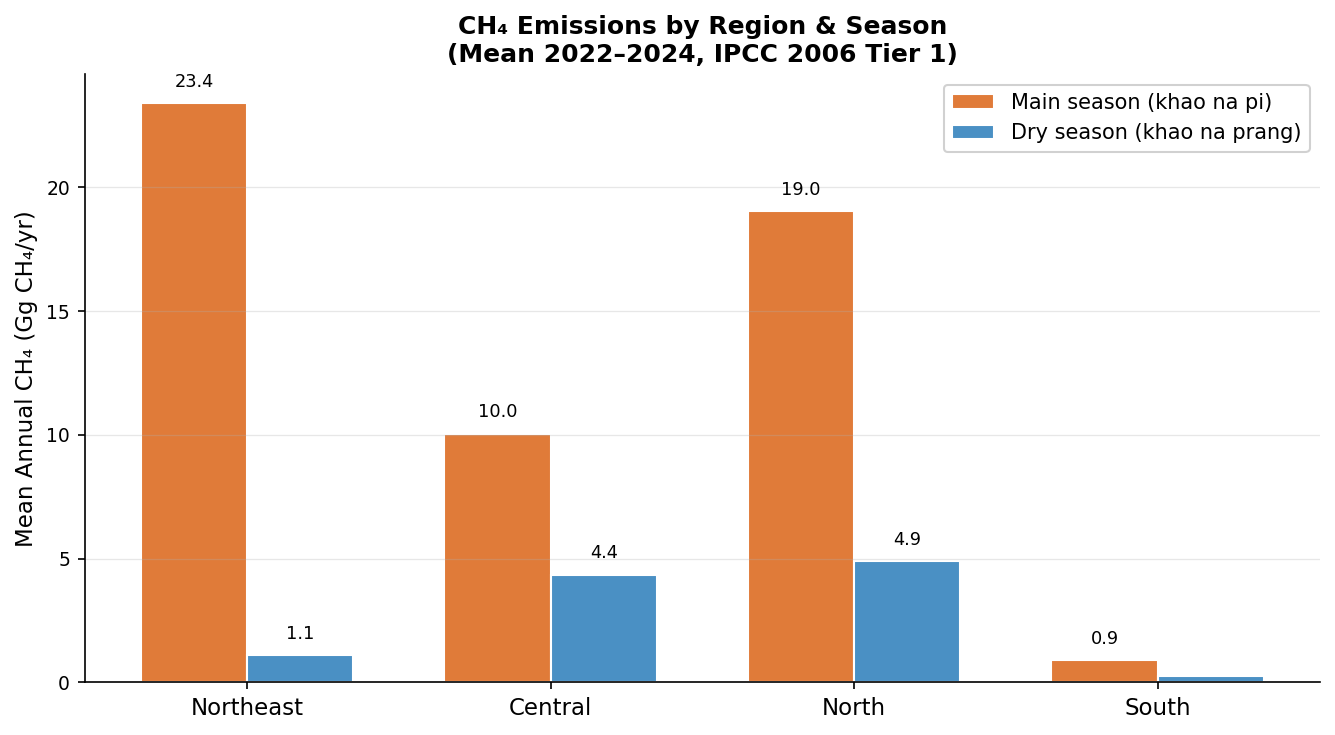

In [4]:
REGION_COLORS = {
    "Northeast": "#d62728",   # strong red
    "Central":   "#2ca02c",   # green
    "North":     "#1f77b4",   # blue
    "South":     "#ff7f00",   # orange
}

# ── Plot 2: Top 20 provinces ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))
top20 = mean_prov.head(20).sort_values("CH4_Gg")
colors = [REGION_COLORS[r] for r in top20["region"]]
bars = ax.barh(top20["province_en"], top20["CH4_Gg"], color=colors, edgecolor="white", lw=0.5)
for bar, val in zip(bars, top20["CH4_Gg"]):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}", va="center", ha="left", fontsize=8.5)
legend_handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=legend_handles, title="Region", fontsize=9, title_fontsize=9,
          loc="lower right")
ax.set_xlabel("Mean Annual CH₄ Emissions (Gg CH₄/yr)", fontsize=11)
ax.set_title("Top 20 Provinces — Rice CH₄ Emissions\n"
             "(Mean 2022–2024, IPCC 2006 Tier 1)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, top20["CH4_Gg"].max()*1.2)
ax.grid(axis="x", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../output/plot2_top20_provinces.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Regional x Season ────────────────────────────────────────────────
region_season = (
    df[df["year_CE"] <= 2024]
    .groupby(["region","season"])["CH4_Gg"].mean()
    .unstack("season").fillna(0)
    .loc[["Northeast","Central","North","South"]]
)
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(region_season)); w = 0.35
b1 = ax.bar(x-w/2, region_season.get("main",0), w,
            label="Main season (khao na pi)", color="#e07b39", edgecolor="white")
b2 = ax.bar(x+w/2, region_season.get("dry",0),  w,
            label="Dry season (khao na prang)", color="#4a90c4", edgecolor="white")
for b in [b1, b2]:
    for bar in b:
        h = bar.get_height()
        if h > 0.5:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f"{h:.1f}",
                    ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(region_season.index, fontsize=11)
ax.set_ylabel("Mean Annual CH₄ (Gg CH₄/yr)", fontsize=11)
ax.set_title("CH₄ Emissions by Region & Season\n"
             "(Mean 2022–2024, IPCC 2006 Tier 1)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../output/plot3_region_season.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 4 — Choropleth Map with North Arrow & Scale Bar

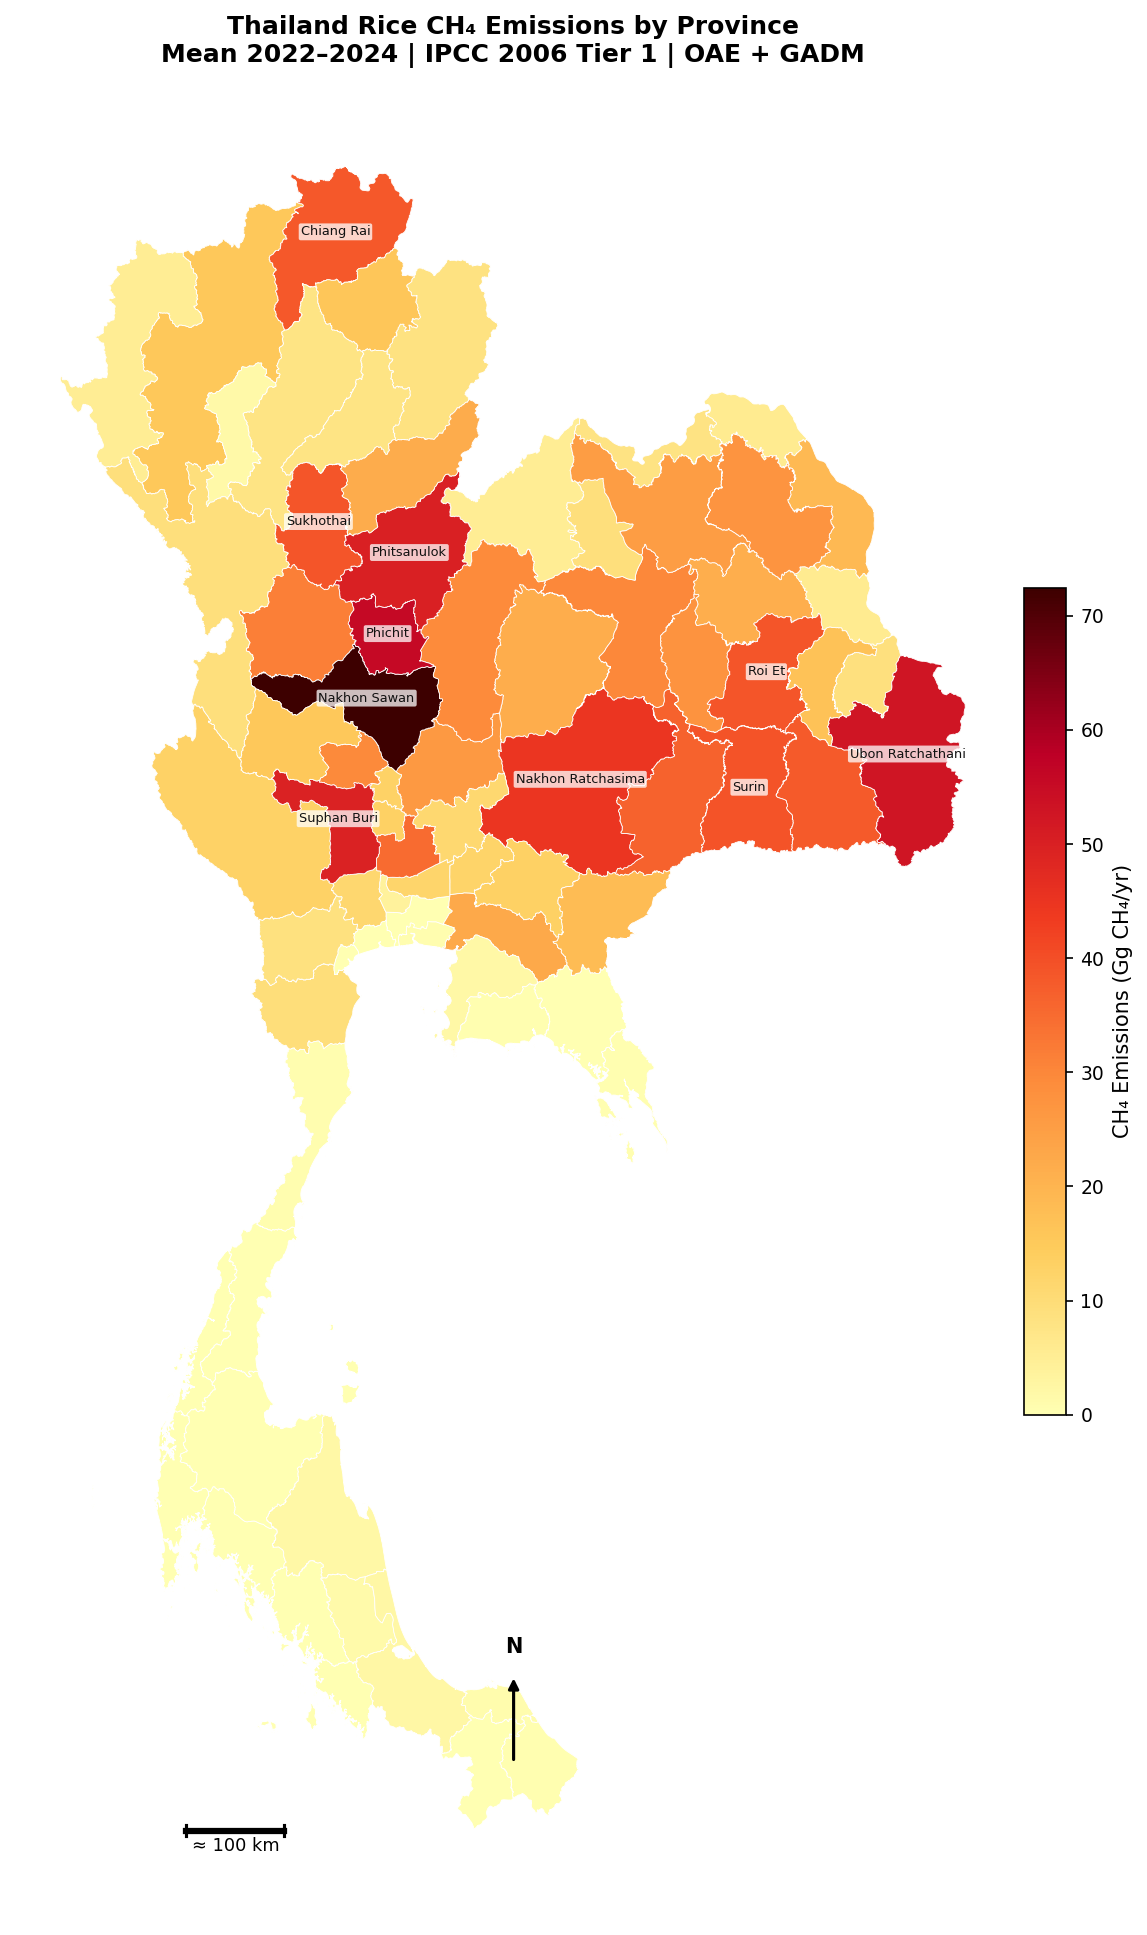

In [5]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Continuous gradient: pale yellow → orange → red → near-black
cmap_yor = LinearSegmentedColormap.from_list(
    "yor_dark",
    ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026", "#3d0000"],
    N=256
)

GADM_FIX = {
    "Krung Thep Maha Nakhon":"Bangkok","Lop Buri":"Lopburi",
    "Nong Bua Lam Phu":"Nong Bua Lamphu",
    "Phra Nakhon Si Ayutthaya":"Phra Nakhon Si Ayutthaya",
}
gdf = gpd.read_file("../resources/gadm_THA/gadm41_THA_1.shp")
gdf["province_en"] = gdf["NAME_1"].map(GADM_FIX).fillna(gdf["NAME_1"])
geo = gdf.merge(mean_prov[["province_en","CH4_Gg","CO2e_Gg","intensity_kgCH4_t"]],
                on="province_en", how="left")
geo["CH4_Gg"] = geo["CH4_Gg"].fillna(0)

vmin = geo["CH4_Gg"].min()
vmax = geo["CH4_Gg"].max()

fig, ax = plt.subplots(figsize=(10, 13))
geo.plot(column="CH4_Gg", ax=ax, cmap=cmap_yor,
         vmin=vmin, vmax=vmax,
         legend=False,
         edgecolor="white", linewidth=0.4,
         missing_kwds={"color":"#eeeeee","label":"No data"})

# Continuous colorbar
sm = ScalarMappable(cmap=cmap_yor, norm=Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical",
                    fraction=0.03, pad=0.01, shrink=0.45)
cbar.set_label("CH₄ Emissions (Gg CH₄/yr)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Label top 10 provinces
for _, row in mean_prov.head(10).iterrows():
    match = geo[geo["province_en"] == row["province_en"]]
    if match.empty: continue
    pt = match.geometry.iloc[0].centroid
    ax.annotate(row["province_en"], xy=(pt.x, pt.y), fontsize=6.2, ha="center",
                color="#111111",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none"))

# ── North arrow ──────────────────────────────────────────────────────────────
x0, y0 = 101.5, 6.2
ax.annotate("", xy=(x0, y0+0.8), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))
ax.text(x0, y0+0.95, "N", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Scale bar ────────────────────────────────────────────────────────────────
sb_x, sb_y, sb_len = 98.5, 5.6, 0.9
ax.plot([sb_x, sb_x+sb_len], [sb_y, sb_y], "k-", lw=3)
ax.plot([sb_x, sb_x],               [sb_y-0.05, sb_y+0.05], "k-", lw=1.5)
ax.plot([sb_x+sb_len, sb_x+sb_len], [sb_y-0.05, sb_y+0.05], "k-", lw=1.5)
ax.text(sb_x+sb_len/2, sb_y-0.18, "≈ 100 km", ha="center", fontsize=8.5)

ax.set_axis_off()
ax.set_title("Thailand Rice CH₄ Emissions by Province\n"
             "Mean 2022–2024 | IPCC 2006 Tier 1 | OAE + GADM",
             fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("../output/plot4_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 5 — Emission Intensity (kg CH₄ per tonne of rice) by Province

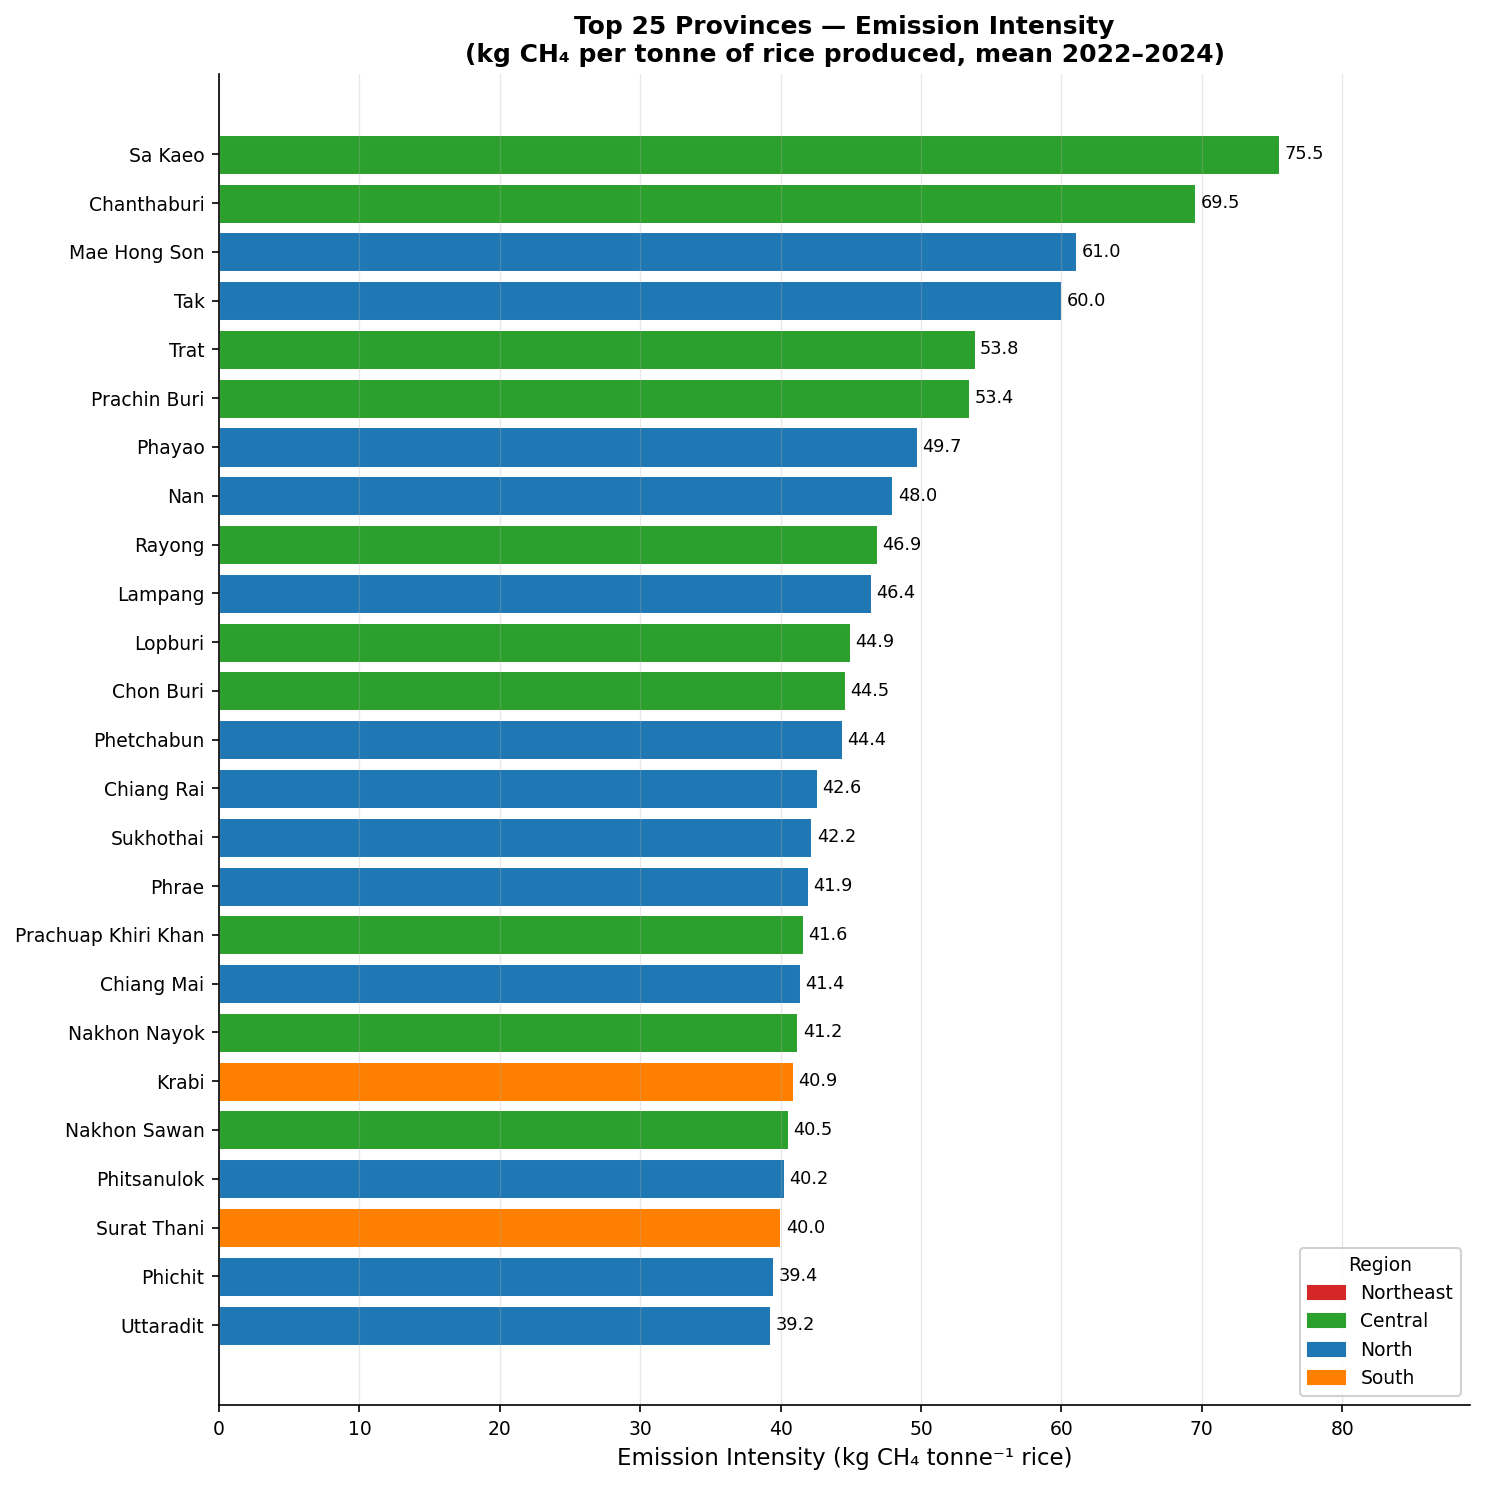

Mean intensity by region (kg CH4/tonne rice):
region
North        44.834903
Central      40.706933
Northeast    33.951348
South        31.436720


In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

top25_int = (mean_prov.dropna(subset=["intensity_kgCH4_t"])
             .nlargest(25, "intensity_kgCH4_t")
             .sort_values("intensity_kgCH4_t"))
colors = [REGION_COLORS[r] for r in top25_int["region"]]
bars = ax.barh(top25_int["province_en"], top25_int["intensity_kgCH4_t"],
               color=colors, edgecolor="white", lw=0.5)
for bar, val in zip(bars, top25_int["intensity_kgCH4_t"]):
    ax.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}", va="center", ha="left", fontsize=8.5)
legend_handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
ax.legend(handles=legend_handles, title="Region", fontsize=9, title_fontsize=9)
ax.set_xlabel("Emission Intensity (kg CH₄ tonne⁻¹ rice)", fontsize=11)
ax.set_title("Top 25 Provinces — Emission Intensity\n"
             "(kg CH₄ per tonne of rice produced, mean 2022–2024)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, top25_int["intensity_kgCH4_t"].max() * 1.18)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../output/plot5_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

reg_int = mean_prov.groupby("region")["intensity_kgCH4_t"].mean().sort_values(ascending=False)
print("Mean intensity by region (kg CH4/tonne rice):")
print(reg_int.to_string())

## Plot 6 — Rice Price vs FAOSTAT Statistics & CH₄: Policy Timeline (2007–2024)

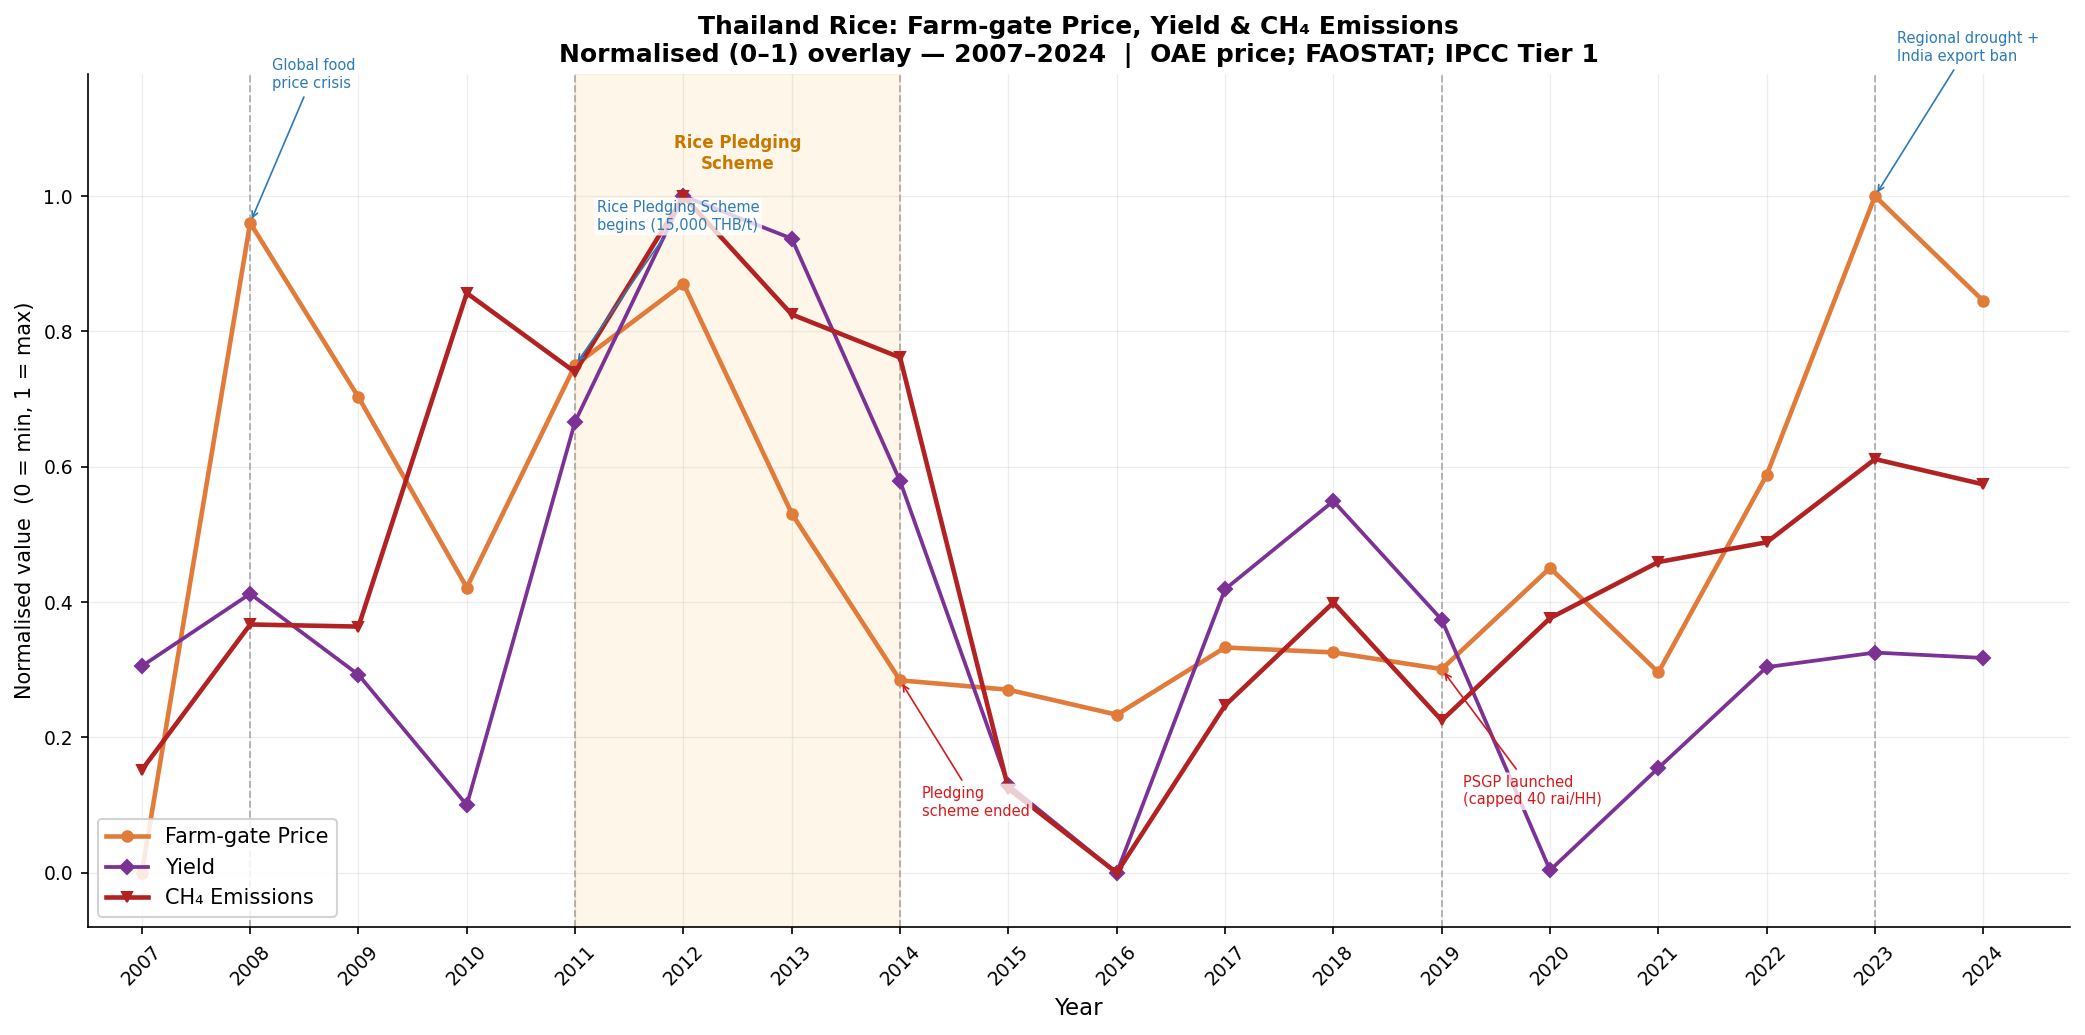

Pearson correlation with farm-gate price (2007–2024):
  Yield                 r=+0.338  p=0.170  
  CH4 Emissions         r=+0.505  p=0.033  *


In [7]:
# ── Load all FAOSTAT elements + price ────────────────────────────────────────
price_df = pd.read_csv("../resources/thailand_rice_price.csv")

nat = pd.read_csv("../resources/FAOSTAT_data_en_5-17-2026.csv")
area_df  = (nat[nat["Element"]=="Area harvested"]
            .rename(columns={"Year":"year","Value":"area_ha"})[["year","area_ha"]]
            .dropna().sort_values("year"))
prod_df  = (nat[nat["Element"]=="Production"]
            .rename(columns={"Year":"year","Value":"production_t"})[["year","production_t"]]
            .dropna().sort_values("year"))
yield_df = (nat[nat["Element"]=="Yield"]
            .rename(columns={"Year":"year","Value":"yield_kg_ha"})[["year","yield_kg_ha"]]
            .dropna().sort_values("year"))
area_df["CH4_Gg"] = area_df["area_ha"] * 153.4 * 1e-6

merged = (area_df[area_df["year"] >= 2007]
          .merge(prod_df,  on="year", how="left")
          .merge(yield_df, on="year", how="left")
          .merge(price_df, on="year", how="left"))

def norm(s): return (s - s.min()) / (s.max() - s.min())

# Harvested Area and Production both omitted:
# - Under Tier 1, CH4 = area × constant EF → CH4 and Area are perfectly collinear.
# - Production closely shadows Area (correlation > 0.95), adding noise not signal.
# Remaining three lines (Price, Yield, CH4) each carry independent information.
VARS = {
    "price_baht_tonne": ("Farm-gate Price",  "#e07b39", 2.2, "o"),
    "yield_kg_ha":      ("Yield",            "#7b3294",  1.8, "D"),
    "CH4_Gg":           ("CH₄ Emissions",    "firebrick",2.2, "v"),
}

POLICIES = [
    (2008, "Global food\nprice crisis",           "top"),
    (2011, "Rice Pledging Scheme\nbegins (15,000 THB/t)", "top"),
    (2014, "Pledging\nscheme ended",               "bottom"),
    (2019, "PSGP launched\n(capped 40 rai/HH)",   "bottom"),
    (2023, "Regional drought +\nIndia export ban", "top"),
]
POL_COL = {"top": "#2c7bb6", "bottom": "#d7191c"}

fig, ax = plt.subplots(figsize=(14, 7))
ax.axvspan(2011, 2014, alpha=0.10, color="#f9a825", zorder=0)
ax.text(2012.5, 1.04, "Rice Pledging\nScheme", ha="center", fontsize=8,
        color="#c77800", fontweight="bold")

yrs = merged["year"].values
for col, (label, color, lw, marker) in VARS.items():
    y = norm(merged[col].values)
    ax.plot(yrs, y, color=color, lw=lw, marker=marker, ms=5, label=label, zorder=3)

for yr, label, pos in POLICIES:
    ax.axvline(yr, color="gray", ls="--", lw=0.9, alpha=0.6, zorder=1)
    row = merged[merged["year"] == yr]
    if row.empty: continue
    idx = list(merged["year"]).index(yr)
    ax1_pval = norm(merged["price_baht_tonne"].values)[idx]
    offset_n = 0.20 if pos == "top" else -0.20
    ax.annotate(label, xy=(yr, ax1_pval),
                xytext=(yr + 0.2, ax1_pval + offset_n),
                fontsize=7, color=POL_COL[pos],
                arrowprops=dict(arrowstyle="->", color=POL_COL[pos], lw=0.8),
                bbox=dict(boxstyle="round,pad=0.18", fc="white", alpha=0.78, ec="none"))

ax.set_xticks(range(2007, 2025))
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(2006.5, 2024.8)
ax.set_ylim(-0.08, 1.18)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Normalised value  (0 = min, 1 = max)", fontsize=10)
ax.set_title(
    "Thailand Rice: Farm-gate Price, Yield & CH₄ Emissions\n"
    "Normalised (0–1) overlay — 2007–2024  |  OAE price; FAOSTAT; IPCC Tier 1",
    fontsize=12, fontweight="bold")
ax.legend(loc="lower left", fontsize=10, framealpha=0.85)
ax.grid(True, alpha=0.22)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../output/plot6_policy_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

print("Pearson correlation with farm-gate price (2007–2024):")
for var, label in [("yield_kg_ha","Yield"), ("CH4_Gg","CH4 Emissions")]:
    sub = merged[["price_baht_tonne", var]].dropna()
    _, _, r, p, _ = stats.linregress(sub["price_baht_tonne"], sub[var])
    print(f"  {label:20s}  r={r:+.3f}  p={p:.3f}  {'*' if p<0.05 else ''}")

## Plot 7 — Thai Rice Calendar & Climate Variability (Yield Anomaly × ENSO)

Bivariate price–area:              r=0.505  p=0.033
Partial (controlling ONI grow.):   r=0.549  p=0.018  n=18


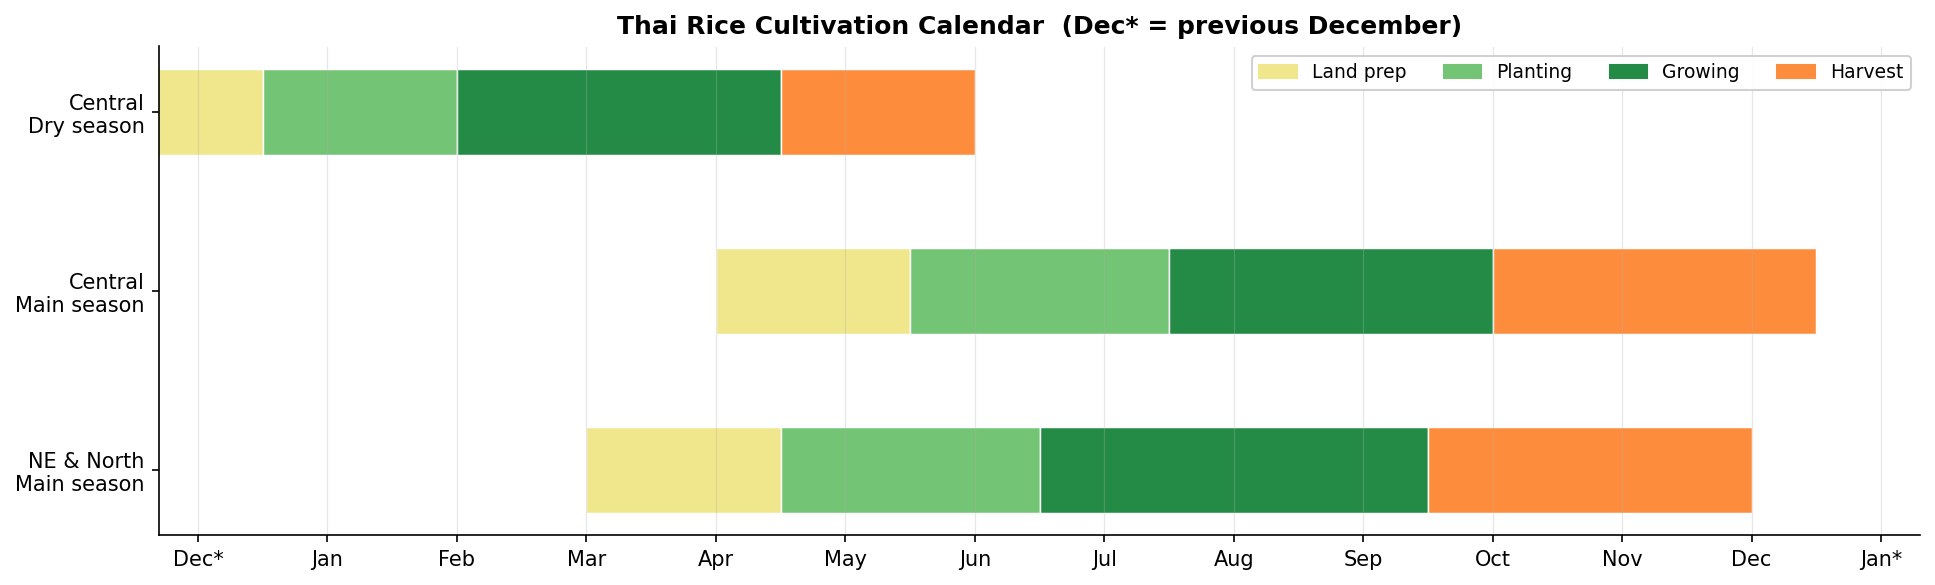

In [8]:
import matplotlib.gridspec as gridspec

# ── Load ONI for partial correlation (stored, not plotted) ───────────────────
oni = pd.read_csv("../resources/oni_growing_season.csv")
price_df2 = pd.read_csv("../resources/thailand_rice_price.csv")

nat2 = pd.read_csv("../resources/FAOSTAT_data_en_5-17-2026.csv")
area2 = nat2[nat2['Element']=='Area harvested'].rename(columns={'Year':'year','Value':'area_ha'})[['year','area_ha']].dropna()
yld2  = nat2[nat2['Element']=='Yield'].rename(columns={'Year':'year','Value':'yield_hg_ha'})[['year','yield_hg_ha']].dropna()
df_pc = area2.merge(yld2, on='year').merge(oni, on='year').merge(price_df2, on='year').dropna()

def partial_resid(x, z):
    s, i, *_ = stats.linregress(z, x)
    return x - (s * z + i)

area_r  = partial_resid(df_pc['area_ha'].values,          df_pc['oni_grow'].values)
price_r = partial_resid(df_pc['price_baht_tonne'].values, df_pc['oni_grow'].values)
rp, pp  = stats.pearsonr(price_r, area_r)
rb, pb  = stats.pearsonr(df_pc['price_baht_tonne'], df_pc['area_ha'])
print(f"Bivariate price–area:              r={rb:.3f}  p={pb:.3f}")
print(f"Partial (controlling ONI grow.):   r={rp:.3f}  p={pp:.3f}  n={len(df_pc)}")

# ════════════════════════════════════════════════════════════════════════════
# Plot 7 — Thai Rice Cultivation Calendar (Panel A only)
# ════════════════════════════════════════════════════════════════════════════
PH = {'Land prep':'#f0e68c', 'Planting':'#74c476',
      'Growing':'#238b45',   'Harvest':'#fd8d3c'}
CAL = [
    ('NE & North\nMain season', 'Land prep', 4.0, 1.5),
    ('NE & North\nMain season', 'Planting',  5.5, 2.0),
    ('NE & North\nMain season', 'Growing',   7.5, 3.0),
    ('NE & North\nMain season', 'Harvest',  10.5, 2.5),
    ('Central\nMain season',    'Land prep', 5.0, 1.5),
    ('Central\nMain season',    'Planting',  6.5, 2.0),
    ('Central\nMain season',    'Growing',   8.5, 2.5),
    ('Central\nMain season',    'Harvest',  11.0, 2.5),
    ('Central\nDry season',     'Land prep', 0.5, 1.0),
    ('Central\nDry season',     'Planting',  1.5, 1.5),
    ('Central\nDry season',     'Growing',   3.0, 2.5),
    ('Central\nDry season',     'Harvest',   5.5, 1.5),
]
ROWS  = ['NE & North\nMain season', 'Central\nMain season', 'Central\nDry season']
ROW_Y = {r: i for i, r in enumerate(ROWS)}

fig, ax = plt.subplots(figsize=(13, 4))
for row, phase, start, dur in CAL:
    ax.barh(ROW_Y[row], dur, left=start-1, height=0.48,
            color=PH[phase], edgecolor='white', lw=0.7)

ph_leg = [mpatches.Patch(color=c, label=l) for l, c in PH.items()]
ax.legend(handles=ph_leg, loc='upper right', fontsize=9, ncol=4, framealpha=0.9)

MONTH_TICKS = list(range(14))
MONTH_LABS  = ['Dec*','Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec','Jan*']
ax.set_xticks(MONTH_TICKS); ax.set_xticklabels(MONTH_LABS, fontsize=10)
ax.set_yticks(range(len(ROWS))); ax.set_yticklabels(ROWS, fontsize=10)
ax.set_xlim(-0.3, 13.3)
ax.set_title('Thai Rice Cultivation Calendar  (Dec* = previous December)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../output/plot7_climate_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 8 — National Emission Intensity (kg CH₄ per tonne), 1961–2024

Intensity trend: -0.730 kg/t/yr | R²=0.892 | p=1.31e-31
1961 intensity: 92.5 kg/t
2024 intensity: 51.4 kg/t


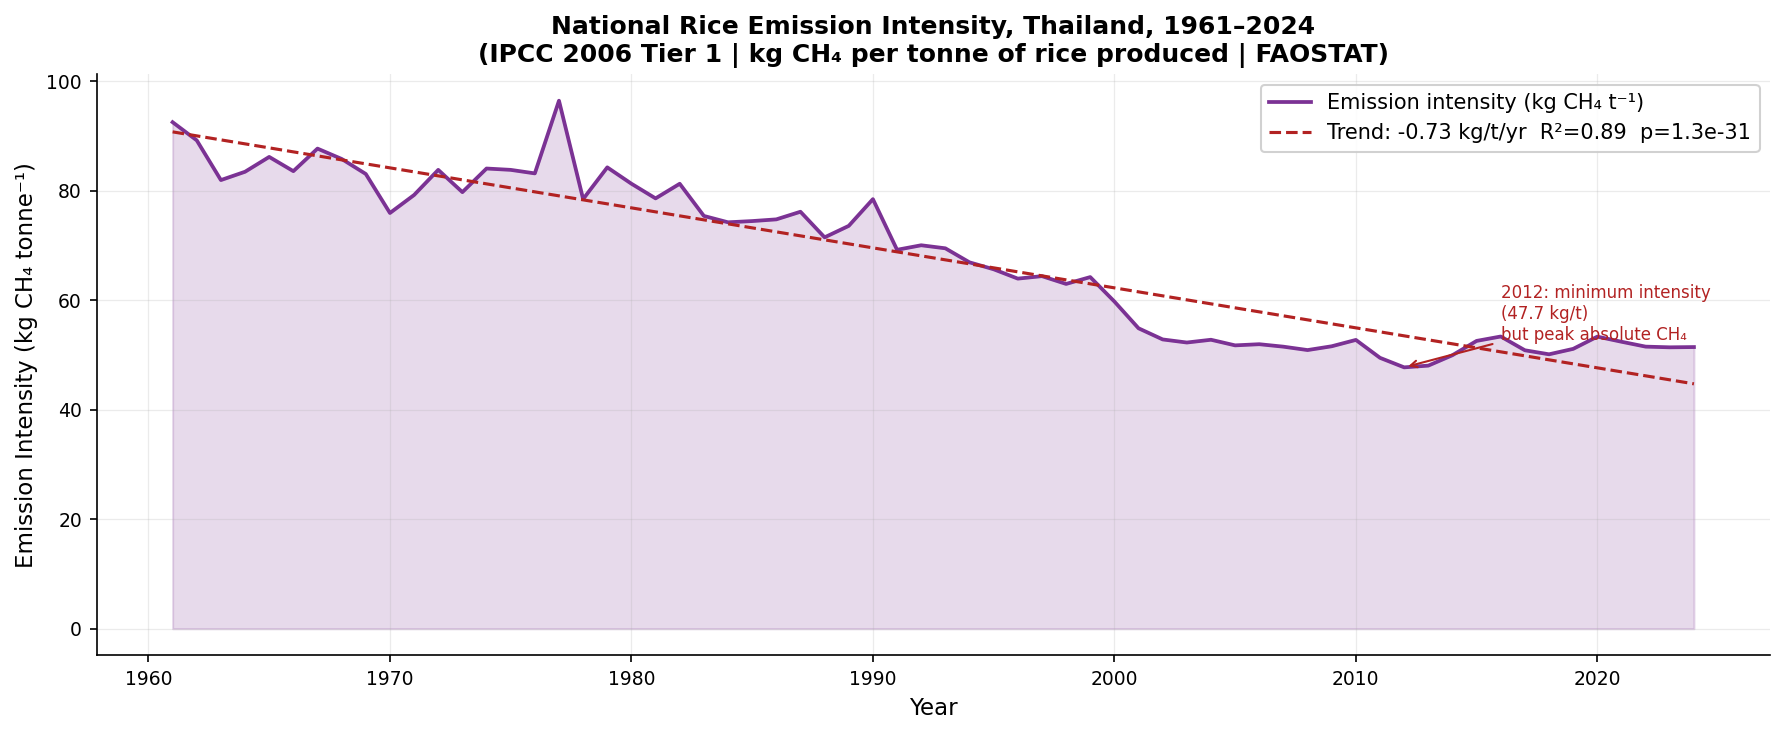

Saved → plot8_yield_efficiency.png


In [9]:
nat_full = pd.read_csv("../resources/FAOSTAT_data_en_5-17-2026.csv")
area_int = (nat_full[nat_full["Element"]=="Area harvested"]
            .rename(columns={"Year":"year","Value":"area_ha"})[["year","area_ha"]]
            .dropna().sort_values("year"))
prod_int = (nat_full[nat_full["Element"]=="Production"]
            .rename(columns={"Year":"year","Value":"production_t"})[["year","production_t"]]
            .dropna().sort_values("year"))

intensity_df = area_int.merge(prod_int, on="year")
intensity_df["CH4_Gg"]        = intensity_df["area_ha"] * 153.4 * 1e-6
intensity_df["intensity_kg_t"] = (intensity_df["CH4_Gg"] * 1e6) / intensity_df["production_t"]

sl, ic, r_int, p_int, _ = stats.linregress(intensity_df["year"], intensity_df["intensity_kg_t"])
trend_int = sl * intensity_df["year"] + ic
print(f"Intensity trend: {sl:.3f} kg/t/yr | R²={r_int**2:.3f} | p={p_int:.2e}")
print(f"1961 intensity: {intensity_df.iloc[0]['intensity_kg_t']:.1f} kg/t")
print(f"2024 intensity: {intensity_df.iloc[-1]['intensity_kg_t']:.1f} kg/t")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(intensity_df["year"], intensity_df["intensity_kg_t"], alpha=0.18, color="#7b3294")
ax.plot(intensity_df["year"], intensity_df["intensity_kg_t"], color="#7b3294", lw=1.8,
        label="Emission intensity (kg CH₄ t⁻¹)")
ax.plot(intensity_df["year"], trend_int, "--", color="firebrick", lw=1.5,
        label=f"Trend: {sl:.2f} kg/t/yr  R²={r_int**2:.2f}  p={p_int:.1e}")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Emission Intensity (kg CH₄ tonne⁻¹)", fontsize=11)
ax.set_title(
    "National Rice Emission Intensity, Thailand, 1961–2024\n"
    "(IPCC 2006 Tier 1 | kg CH₄ per tonne of rice produced | FAOSTAT)",
    fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
ax.spines[["top","right"]].set_visible(False)

# Annotate 2012 paradox point
yr2012 = intensity_df[intensity_df["year"]==2012].iloc[0]
ax.annotate(f"2012: minimum intensity\n({yr2012['intensity_kg_t']:.1f} kg/t)\nbut peak absolute CH₄",
            xy=(2012, yr2012["intensity_kg_t"]),
            xytext=(2016, yr2012["intensity_kg_t"]+5),
            fontsize=8, color="firebrick",
            arrowprops=dict(arrowstyle="->", color="firebrick", lw=1))

plt.tight_layout()
plt.savefig("../output/plot8_yield_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot8_yield_efficiency.png")

## Plot 9 — AWD Mitigation Priority Ranking by Province (fixed sort)

Top 10 AWD priority provinces (sorted by 50% scenario potential, descending):
             province_en  region  dry_CH4_Gg  awd30_Gg  awd50_Gg
             Suphan Buri Central   19.386971  5.816091  9.693485
             Phitsanulok   North   15.683072  4.704922  7.841536
Phra Nakhon Si Ayutthaya Central   15.503234  4.650970  7.751617
            Nakhon Sawan Central   15.294270  4.588281  7.647135
                 Phichit   North   13.916431  4.174929  6.958215
          Kamphaeng Phet   North   11.706649  3.511995  5.853325
               Sukhothai   North   11.529483  3.458845  5.764742
                Chai Nat Central    9.512423  2.853727  4.756212
              Chiang Rai   North    9.236533  2.770960  4.618267
               Uttaradit   North    7.208345  2.162503  3.604172


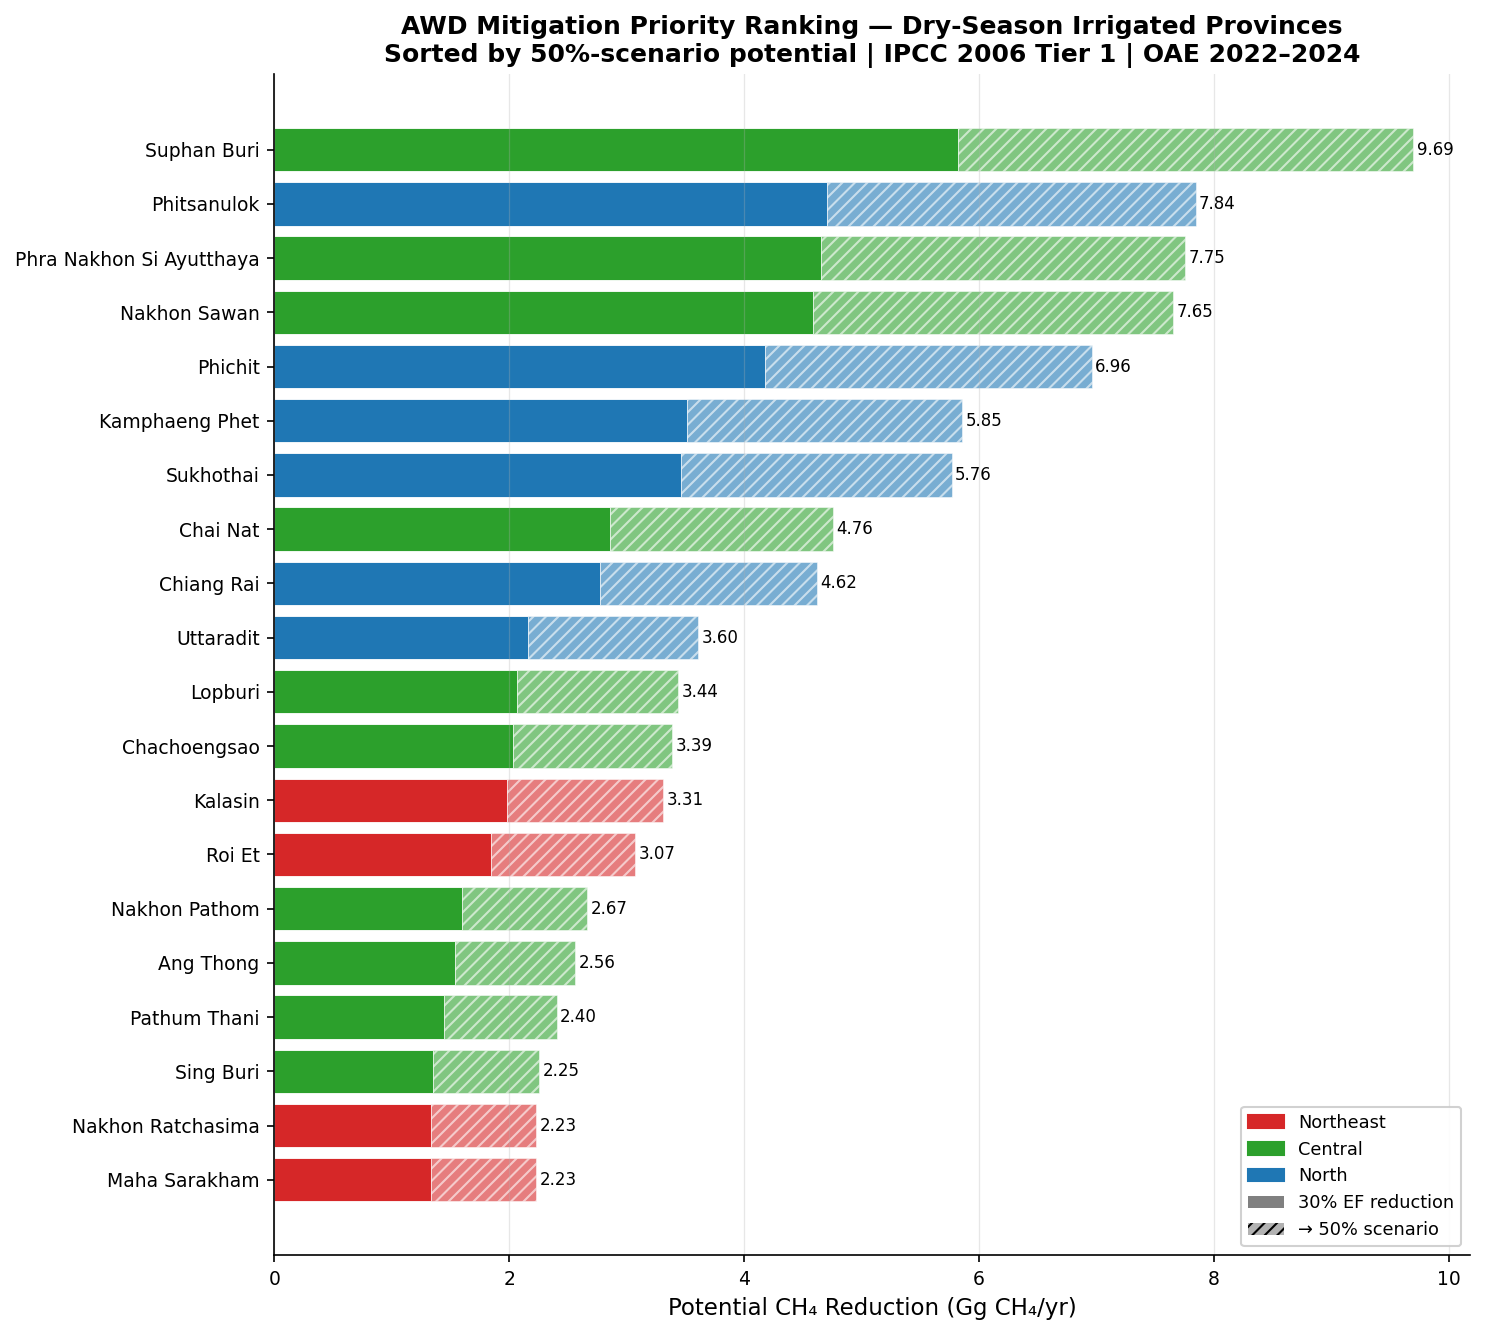

Saved → plot9_awd_priority.png


In [10]:
# AWD applies only to dry-season irrigated area (water control is feasible)
dry_df = df[df["season"] == "dry"].copy()
dry_df["EF_kg_ha"] = T_P["dry"] * EF_c
dry_df["CH4_Gg"]   = dry_df["area_harvested_ha"] * dry_df["EF_kg_ha"] * 1e-6

dry_prov = (
    dry_df.groupby(["province_en", "region"])
    .agg(dry_area_ha=("area_harvested_ha", "mean"),
         dry_CH4_Gg=("CH4_Gg", "mean"))
    .reset_index()
)
# AWD scenarios: 30% EF reduction (solid bar) + extension to 50% (hatched)
dry_prov["awd30_Gg"] = dry_prov["dry_CH4_Gg"] * 0.30
dry_prov["awd50_Gg"] = dry_prov["dry_CH4_Gg"] * 0.50
dry_prov["ext20_Gg"] = dry_prov["awd50_Gg"] - dry_prov["awd30_Gg"]

# Sort by 50%-scenario total descending (priority = highest mitigation potential first)
dry_prov = dry_prov.sort_values("awd50_Gg", ascending=False).reset_index(drop=True)
top_n = dry_prov[dry_prov["awd50_Gg"] > 0].head(20)
# For barh: ascending=True so largest value ends up at the TOP of the chart
plot_data = top_n.sort_values("awd50_Gg", ascending=True).reset_index(drop=True)

print("Top 10 AWD priority provinces (sorted by 50% scenario potential, descending):")
print(top_n.head(10)[["province_en","region","dry_CH4_Gg","awd30_Gg","awd50_Gg"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 9))
colors = [REGION_COLORS[r] for r in plot_data["region"]]

# Solid bar: 30% reduction potential
ax.barh(plot_data["province_en"], plot_data["awd30_Gg"],
        color=colors, edgecolor="white", lw=0.4,
        label="30% EF reduction (AWD scenario)")
# Hatched extension: 30% → 50%
ax.barh(plot_data["province_en"], plot_data["ext20_Gg"],
        left=plot_data["awd30_Gg"],
        color=colors, edgecolor="white", lw=0.4, hatch="////", alpha=0.6,
        label="+20 pp extension (50% scenario)")

# Value labels (one loop only, using enumerate for categorical y positions)
for i, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(row["awd50_Gg"] + 0.03, i, f"{row['awd50_Gg']:.2f}",
            va="center", ha="left", fontsize=8)

legend_handles = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()
                  if r in plot_data["region"].values]
legend_handles += [
    mpatches.Patch(facecolor="gray", label="30% EF reduction"),
    mpatches.Patch(facecolor="gray", hatch="////", alpha=0.6, label="→ 50% scenario"),
]
ax.legend(handles=legend_handles, fontsize=8.5, loc="lower right")
ax.set_xlabel("Potential CH₄ Reduction (Gg CH₄/yr)", fontsize=11)
ax.set_title(
    "AWD Mitigation Priority Ranking — Dry-Season Irrigated Provinces\n"
    "Sorted by 50%-scenario potential | IPCC 2006 Tier 1 | OAE 2022–2024",
    fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../output/plot9_awd_priority.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plot9_awd_priority.png")

## Robustness Check — Policy Dummy & Interrupted Time Series (ITS)
Tests whether the Rice Pledging Scheme (2011–2014) explains area variance beyond price alone. Two approaches:
1. **OLS with policy dummy**: area ~ price + pledging_dummy
2. **Chow test**: structural break at 2011 in price–area relationship

In [11]:
# ─── Policy dummy & ITS analysis ───────────────────────────────────────────
from scipy import stats
from scipy.stats import f as fdist
import numpy as np

price_df3 = pd.read_csv('../resources/thailand_rice_price.csv')
nat3 = pd.read_csv('../resources/FAOSTAT_data_en_5-17-2026.csv')
area3 = (nat3[nat3['Element']=='Area harvested']
          .rename(columns={'Year':'year','Value':'area_ha'})
          [['year','area_ha']].dropna().sort_values('year'))
m3 = area3.merge(price_df3, on='year').dropna()

# Policy dummy: 1 for 2011-2014 (Rice Pledging Scheme active)
m3 = m3.copy()
m3['pledging'] = ((m3['year'] >= 2011) & (m3['year'] <= 2014)).astype(int)
n = len(m3)
Y = m3['area_ha'].values
ss_tot = np.sum((Y - Y.mean())**2)

def ols(X, y):
    b, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ b
    ss = np.sum((y - yhat)**2)
    return b, ss

# ── Model 1: price only ────────────────────────────────────────────────────
X1 = np.column_stack([np.ones(n), m3['price_baht_tonne']])
b1, ss1 = ols(X1, Y)
r2_1 = 1 - ss1/ss_tot
_, _, r1, p1, _ = stats.linregress(m3['price_baht_tonne'], Y)
print(f"Model 1 (price only):       r={r1:.3f}  p={p1:.3f}  R²={r2_1:.3f}")

# ── Model 2: price + pledging dummy ───────────────────────────────────────
X2 = np.column_stack([np.ones(n), m3['price_baht_tonne'], m3['pledging']])
b2, ss2 = ols(X2, Y)
r2_2 = 1 - ss2/ss_tot
F_add = ((ss1-ss2)/1) / (ss2/(n-3))
p_add = 1 - fdist.cdf(F_add, 1, n-3)
print(f"Model 2 (price + dummy):    R²={r2_2:.3f}")
print(f"  β_intercept = {b2[0]/1e6:.2f} M ha")
print(f"  β_price     = {b2[1]:.0f} ha per THB/t")
print(f"  β_pledging  = {b2[2]/1e6:.2f} M ha  (Pledging Scheme area premium)")
print(f"  F-test (dummy adds):  F={F_add:.2f}  p={p_add:.3f}  {'*' if p_add<0.05 else 'n.s.'}")

# ── Chow test: structural break at 2011 ───────────────────────────────────
pre  = m3[m3['year'] < 2011]
post = m3[m3['year'] >= 2011]

def seg_ols_ss(df):
    x = df['price_baht_tonne'].values
    y = df['area_ha'].values
    X = np.column_stack([np.ones(len(x)), x])
    _, ss = ols(X, y)
    return ss, len(df)

ss_pre, n_pre   = seg_ols_ss(pre)
ss_post, n_post = seg_ols_ss(post)
k = 2
chow_F = ((ss1 - (ss_pre+ss_post))/k) / ((ss_pre+ss_post)/(n-2*k))
p_chow = 1 - fdist.cdf(chow_F, k, n-2*k)
print(f"\nChow test (break at 2011):  F={chow_F:.2f}  p={p_chow:.3f}  {'*' if p_chow<0.05 else 'n.s.'}")
print(f"  Pre-2011  mean area: {pre['area_ha'].mean()/1e6:.2f} M ha  (n={n_pre})")
print(f"  Post-2011 mean area: {post['area_ha'].mean()/1e6:.2f} M ha  (n={n_post})")
print(f"  Difference:          {(post['area_ha'].mean()-pre['area_ha'].mean())/1e6:+.2f} M ha")
EF_national = 153.4  # kg/ha, main season (Buddhaboon et al. 2011)
print(f"\nNote: CH4 = {EF_national}e-6 * area_ha (main season EF, linear Tier 1 scaling).")
print("All area statistics translate directly to CH4 by multiplying by {EF_national}e-6.")

Model 1 (price only):       r=0.505  p=0.033  R²=0.255
Model 2 (price + dummy):    R²=0.631
  β_intercept = 8.87 M ha
  β_price     = 222 ha per THB/t
  β_pledging  = 0.99 M ha  (Pledging Scheme area premium)
  F-test (dummy adds):  F=15.27  p=0.001  *

Chow test (break at 2011):  F=0.98  p=0.401  n.s.
  Pre-2011  mean area: 10.91 M ha  (n=4)
  Post-2011 mean area: 11.04 M ha  (n=14)
  Difference:          +0.13 M ha

Note: CH4 = 153.4e-6 * area_ha (main season EF, linear Tier 1 scaling).
All area statistics translate directly to CH4 by multiplying by {EF_national}e-6.
